In [ ]:
import os 
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
import torch 
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)
from omegaconf import OmegaConf
import torch 
import numpy as np
import random
from compo_predictive_learning.models import create_model
import hydra
import logging
from collections import defaultdict
from compo_predictive_learning.datasets import make_sketch_dataloaders
logger = logging.getLogger(__name__)


In [2]:

def set_seed(seed=0):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

np.set_printoptions(precision=5, suppress=True, linewidth=200)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [3]:
from hydra import initialize, initialize_config_module, initialize_config_dir, compose

with initialize_config_dir(version_base=None, config_dir="/home/ghb24/paper_git/er/comp_predictive_learning/scripts/configs"):
    config = compose(config_name="train_rnn.yaml")


/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'train_rnn.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [4]:
config.rnn.activation = "tanh"

In [5]:
set_seed(config.seed)   
pretrain_loader,val_loader, smaller_pretrain_loader,analysis_loader,classification_metric_train_loaders, classification_metric_val_loaders,latent_names, train_contexts,val_contexts = make_sketch_dataloaders(config)

all_contexts = train_contexts + val_contexts

model = create_model(config).to(DEVICE)


--- Generating Support: 'full' ---
Total contexts: 54
Train contexts: 43
Validation contexts: 11


/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/torch/utils/data/sampler.py:76: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Output shape from conv layers 1024


In [6]:
# model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/test/contextual_full_1_0.8/sketch_6/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2, 3, 4, 5]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_256_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0.01_0_0_128/seed0/model_step_4999.pth"))

model.load_state_dict(torch.load("/home/ghb24/paper_git/er/comp_predictive_learning/revieww/contextual_full_1_0.8/sketch_6/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2, 3, 4, 5]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_512_tanh_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.0001_0.001_0_0_128/seed0/model_step_4999.pth"))
# model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/test/contextual_full_1_0.8/sketch_6_4/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_512_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0.01_0_0_128/seed0/model_step_4999.pth"))

/tmp/ipykernel_3254911/209621624.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home/ghb24/paper_git/er/comp_predictive_learning/revi

<All keys matched successfully>

In [7]:
import matplotlib.pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.309571..0.97414213].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18169539..0.6027529].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.24105828..1.1621782].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13669908..1.2627203].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.14285655..1.0337378].


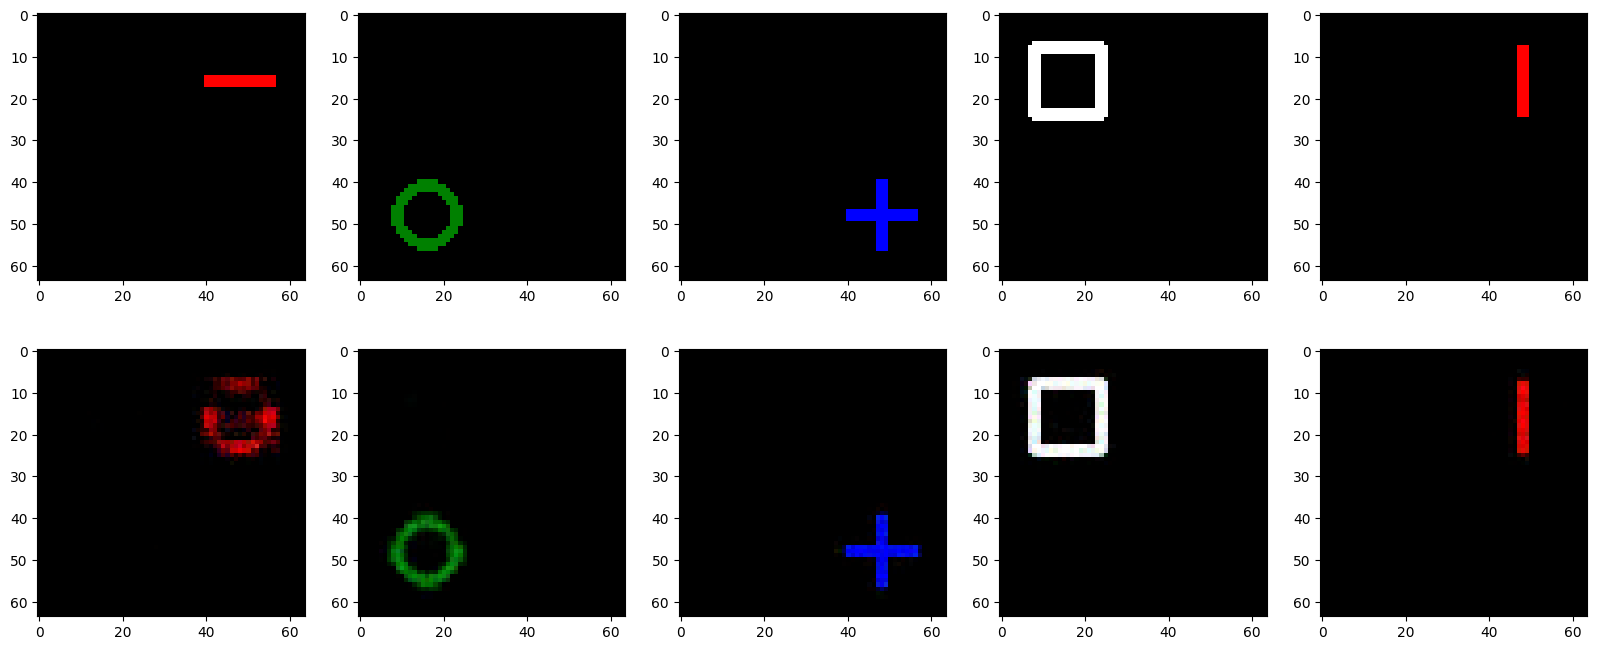

In [8]:
for batch in val_loader:
    imgs, latents, contexts = batch
    out,cnn_encoded,rnn_out,_ = model(imgs)

    fix,ax = plt.subplots(2,5, figsize=(20,8))
    for i in range(5):
        ax[0][i].imshow(imgs[i+1,0].cpu().numpy().transpose(1,2,0))
        ax[1][i].imshow(out[i,0].detach().cpu().numpy().transpose(1,2,0))
    break

In [9]:
import torch 
from sklearn.svm import LinearSVC
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def unpack_batch(batch):
    if len(batch) == 3:
        prim_sequence_inputs, latents, contexts = batch
    else:   
        prim_sequence_inputs, latents = batch
    prim_sequence_inputs = prim_sequence_inputs.transpose(0,1).to(DEVICE)
    latents = latents.transpose(0,1).to(DEVICE)
    return prim_sequence_inputs, latents

def disentanglement_metric(
            config,
             model,
             train_loader,
             val_loader,
             idx_to_classify):
    
    model.train()
    def get_activity_and_labels_b(loader):
        acti = []
        labels = []
        with torch.no_grad():
            for batch in loader:
                prim_sequence_inputs, latents = unpack_batch(batch)
                _,_,activity,_ = model(prim_sequence_inputs)
                acti.append(activity[-1:].cpu().flatten(0,1))
                labels.append(latents[-1:].cpu().flatten(0,1))
        return torch.cat(acti, dim=0), torch.cat(labels, dim=0)

    train_activities, train_latents = get_activity_and_labels_b(train_loader)
    val_activities, val_latents = get_activity_and_labels_b(val_loader)
    classifier =  LinearSVC(max_iter=5000,penalty="l1",C=10,random_state=0)
    classifier.fit(train_activities.numpy(), train_latents[:,idx_to_classify].cpu().numpy())
    latent_neurons = torch.abs(torch.from_numpy(classifier.coef_)).sum(dim=0) > 0
    train_acc = classifier.score(train_activities.numpy(), train_latents[:,idx_to_classify].cpu().numpy())
    val_acc = classifier.score(val_activities.numpy(), val_latents[:,idx_to_classify].cpu().numpy())

    return train_acc, val_acc,latent_neurons


def neurons_for_dynamic(
            config,
             model,
             train_loader,
             val_loader,
             latent_idx,
             ):
    
    model.train()
    def get_activity_and_labels_b(loader):
        acti = []
        labels = []
        with torch.no_grad():
            for batch in loader:
                prim_sequence_inputs, latents = unpack_batch(batch)
                _,_,activity,_ = model(prim_sequence_inputs)
                acti.append(activity[-1:].cpu().flatten(0,1))
                labels.append(latents[-1:].cpu().flatten(0,1))
        return torch.cat(acti, dim=0), torch.cat(labels, dim=0)

    train_activities, train_latents = get_activity_and_labels_b(train_loader)
    val_activities, val_latents = get_activity_and_labels_b(val_loader)
    classifier =  LinearSVC(max_iter=5000,penalty="l1",C=10,random_state=0)
    classifier.fit(train_activities.numpy(), train_latents[:,idx_to_classify].cpu().numpy())
    latent_neurons = torch.abs(torch.from_numpy(classifier.coef_)).sum(dim=0) > 0
    train_acc = classifier.score(train_activities.numpy(), train_latents[:,idx_to_classify].cpu().numpy())
    val_acc = classifier.score(val_activities.numpy(), val_latents[:,idx_to_classify].cpu().numpy())

    return train_acc, val_acc,latent_neurons



In [10]:
latents = ["primitive", "color", "quadrant"]
latent_idx = 0

In [11]:
latents_to_neurons = defaultdict(torch.Tensor)
train_accs = {}
val_accs = {}
neurons_intersection  = torch.ones(512, dtype=torch.bool)
for lat in classification_metric_train_loaders.keys():
    classification_metric_train_loader,lat_idx = classification_metric_train_loaders[lat]
    classification_metric_val_loader = classification_metric_val_loaders[lat][0]
    train_acc,val_acc,latent_neurons = disentanglement_metric(config, model, idx_to_classify=lat_idx, train_loader=classification_metric_train_loader, val_loader=classification_metric_val_loader)
    latents_to_neurons[lat] = latent_neurons
    train_accs[lat] = train_acc
    val_accs[lat] = val_acc
    print(f"Latent: {lat}, Train acc: {train_acc}, Val acc: {val_acc}, Num neurons: {latent_neurons.sum().item()}")
    neurons_intersection = neurons_intersection & latent_neurons
print(f"Intersection of neurons across latents: {neurons_intersection.sum().item()}")

/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Latent: primitive, Train acc: 1.0, Val acc: 1.0, Num neurons: 35
Latent: color, Train acc: 1.0, Val acc: 1.0, Num neurons: 20
Latent: position, Train acc: 1.0, Val acc: 1.0, Num neurons: 20
Intersection of neurons across latents: 1


In [12]:
import torch
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif

import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def unpack_batch_inputs_contexts_latents(batch):
    """
    Expected order per your message: (inputs, contexts, latents)
    But also supports (inputs, latents, contexts) by checking dims:
      - contexts: [B, L] (2D)
      - latents:  [B, T, L] or [T, B, L] (3D)
    Returns:
      x: [T, B, ...] on DEVICE
      lat: [T, B, L] on DEVICE (or None if not present)
      ctx: [B, L] on DEVICE
    """
    if len(batch) == 3:
        x, a, b = batch
        if a.dim() == 2 and b.dim() == 3:
            ctx, lat = a, b
        elif b.dim() == 2 and a.dim() == 3:
            lat, ctx = a, b
        elif a.dim() == 2 and b.dim() == 2:
            # rare; treat b as latents missing time; keep lat None
            ctx, lat = a, None
        else:
            # fallback: assume (x, ctx, lat)
            ctx, lat = a, b
    elif len(batch) == 2:
        x, ctx = batch
        lat = None
    else:
        raise ValueError(f"Unexpected batch length: {len(batch)}")

    # put time first for x
    if x.dim() >= 2 and x.shape[0] != x.shape[1]:
        # typical: [B,T,...] -> [T,B,...]
        x = x.transpose(0, 1)
    x = x.to(DEVICE)

    if lat is not None:
        if lat.dim() == 3:
            lat = lat.transpose(0, 1).to(DEVICE)  # [T,B,L]
        else:
            lat = lat.to(DEVICE)

    ctx = ctx.to(DEVICE)  # [B,L]
    return x, lat, ctx


def mask_only_target_moves(ctx, latent_idx, *, zero_tol=1e-9, use_abs=True):
    """
    ctx: [B, L] step sizes (discrete)
    Returns:
      mask: [B] True where only ctx[:,latent_idx] is non-zero
      step: [B] the step value for the target latent
    """
    c = ctx.abs() if use_abs else ctx
    step = c[:, latent_idx]  # [B]

    # others are ~0
    others = torch.cat([c[:, :latent_idx], c[:, latent_idx+1:]], dim=1)
    others_zero = (others.abs() <= zero_tol).all(dim=1)

    target_nonzero = step.abs() >= 0
    mask = others_zero & target_nonzero
    return mask, step


def collect_jacobian_by_step_value(
    model,
    loader,
    latent_idx,
    *,
    activity_start_recording=None,
    zero_tol=1e-9,
    use_abs_context=True,
    subsample_batch=1,
    # memory control
    max_points_per_step=20000,  # cap samples per step value
    seed=0,
):
    """
    Returns:
      activity_by_step: dict {float_step_value: np.ndarray [M, N]}
        where rows are activity samples (across time and sequences).
    """
    rng = np.random.default_rng(seed)
    jacobian_per_dynamic = defaultdict(list)  # step -> list of numpy blocks

    model.eval()

    for batch in loader:
        x, latents, ctx = batch  # x [T,B,...], ctx [B,L]
        if subsample_batch < 1:
            B = ctx.shape[0]
            idx = rng.choice(B, size=int(B * subsample_batch), replace=False)
            x = x[:, idx]
            ctx = ctx[idx]
        mask, step = mask_only_target_moves(ctx, latent_idx, zero_tol=zero_tol, use_abs=use_abs_context)

        if mask.sum().item() == 0:
            continue

        # forward pass
        J = model.jacobian_of_rnn_hidden_to_last_hidden(x)  # list of [B,N,N] 

        if activity_start_recording is not None:
            J = J[activity_start_recording:]

        latent_ctx = ctx[0, latent_idx]  # [B]
        assert ctx[0, latent_idx] == ctx[1, latent_idx]

        jacobian_per_dynamic[latent_ctx.item()].append(J[mask].cpu().numpy())

    # concatenate + cap per step
    out = {}
    for s, blocks in jacobian_per_dynamic.items():
        X = np.concatenate(blocks, axis=0)  # [M,N]
        if max_points_per_step is not None and X.shape[0] > max_points_per_step:
            idx = rng.choice(X.shape[0], size=max_points_per_step, replace=False)
            X = X[idx]
        out[s] = X

    if len(out) == 0:
        raise RuntimeError("No samples found where only the requested latent moves. "
                           "Check your context encoding / zero_tol / latent_idx.")
    return out

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def effective_rank_from_singular_values(s):
    p = s / (s.sum() + 1e-12)
    H = -(p * np.log(p + 1e-12)).sum()
    return float(np.exp(H))

def summarize_jacobians(Jmats, *, n_sing=10):
    """
    Jmats: [M,N,N]
    Returns dict of arrays over samples and means.
    """
    M, N, _ = Jmats.shape
    spec_rad = np.zeros(M)
    top_sing = np.zeros((M, n_sing))
    eff_rank = np.zeros(M)

    for i in range(M):
        J = Jmats[i]
        # eigenvalues for spectral radius
        ev = np.linalg.eigvals(J)
        spec_rad[i] = np.max(np.abs(ev))
        # singular values
        s = np.linalg.svd(J, compute_uv=False)
        top_sing[i] = s[:n_sing]
        eff_rank[i] = effective_rank_from_singular_values(s)

    return {
        "spec_rad": spec_rad,
        "top_sing": top_sing,
        "eff_rank": eff_rank,
        "spec_rad_mean": float(spec_rad.mean()),
        "eff_rank_mean": float(eff_rank.mean()),
        "top_sing_mean": top_sing.mean(axis=0),
    }

def plot_summary_vs_step(jacobian_by_step, *, n_sing=5):
    steps = sorted(jacobian_by_step.keys())
    spec = []
    ernk = []
    sing = []

    for s in steps:
        summ = summarize_jacobians(jacobian_by_step[s], n_sing=n_sing)
        spec.append(summ["spec_rad_mean"])
        ernk.append(summ["eff_rank_mean"])
        sing.append(summ["top_sing_mean"])

    sing = np.array(sing)  # [S, n_sing]

    plt.figure()
    plt.plot(steps, spec, marker="o")
    plt.xlabel("step size (dynamic)")
    plt.ylabel("mean spectral radius")
    plt.title("Stability vs dynamic")
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(steps, ernk, marker="o")
    plt.xlabel("step size (dynamic)")
    plt.ylabel("mean effective rank")
    plt.title("Structure/low-rank vs dynamic")
    plt.tight_layout()
    plt.show()

    plt.figure()
    for k in range(n_sing):
        plt.plot(steps, sing[:, k], marker="o", label=f"σ{k+1}")
    plt.xlabel("step size (dynamic)")
    plt.ylabel("mean top singular values")
    plt.title("Amplification directions vs dynamic")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
jac_by_step = collect_jacobian_by_step_value(
    model, analysis_loader, latent_idx=0,
    activity_start_recording=5,
    max_points_per_step=500,
)

In [ ]:


plot_summary_vs_step(jac_by_step, n_sing=5)

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 10.57 GiB of which 2.31 MiB is free. Including non-PyTorch memory, this process has 10.55 GiB memory in use. Of the allocated memory 10.31 GiB is allocated by PyTorch, and 5.17 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [13]:
import torch
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif

import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def unpack_batch_inputs_contexts_latents(batch):
    """
    Expected order per your message: (inputs, contexts, latents)
    But also supports (inputs, latents, contexts) by checking dims:
      - contexts: [B, L] (2D)
      - latents:  [B, T, L] or [T, B, L] (3D)
    Returns:
      x: [T, B, ...] on DEVICE
      lat: [T, B, L] on DEVICE (or None if not present)
      ctx: [B, L] on DEVICE
    """
    if len(batch) == 3:
        x, a, b = batch
        if a.dim() == 2 and b.dim() == 3:
            ctx, lat = a, b
        elif b.dim() == 2 and a.dim() == 3:
            lat, ctx = a, b
        elif a.dim() == 2 and b.dim() == 2:
            # rare; treat b as latents missing time; keep lat None
            ctx, lat = a, None
        else:
            # fallback: assume (x, ctx, lat)
            ctx, lat = a, b
    elif len(batch) == 2:
        x, ctx = batch
        lat = None
    else:
        raise ValueError(f"Unexpected batch length: {len(batch)}")

    # put time first for x
    if x.dim() >= 2 and x.shape[0] != x.shape[1]:
        # typical: [B,T,...] -> [T,B,...]
        x = x.transpose(0, 1)
    x = x.to(DEVICE)

    if lat is not None:
        if lat.dim() == 3:
            lat = lat.transpose(0, 1).to(DEVICE)  # [T,B,L]
        else:
            lat = lat.to(DEVICE)

    ctx = ctx.to(DEVICE)  # [B,L]
    return x, lat, ctx


def mask_only_target_moves(ctx, latent_idx, *, zero_tol=1e-9, use_abs=True):
    """
    ctx: [B, L] step sizes (discrete)
    Returns:
      mask: [B] True where only ctx[:,latent_idx] is non-zero
      step: [B] the step value for the target latent
    """
    c = ctx.abs() if use_abs else ctx
    step = c[:, latent_idx]  # [B]

    # others are ~0
    others = torch.cat([c[:, :latent_idx], c[:, latent_idx+1:]], dim=1)
    others_zero = (others.abs() <= zero_tol).all(dim=1)

    target_nonzero = step.abs() >= 0
    mask = others_zero & target_nonzero
    return mask, step


@torch.no_grad()
def collect_activity_by_step_value(
    model,
    loader,
    latent_idx,
    *,
    activity_start_recording=None,
    feature="delta_activity",   # "activity" or "delta_activity"
    zero_tol=1e-9,
    use_abs_context=True,
    # memory control
    max_points_per_step=20000,  # cap samples per step value
    time_subsample=1,           # take every k-th timestep
    seed=0,
):
    """
    Returns:
      activity_by_step: dict {float_step_value: np.ndarray [M, N]}
        where rows are activity samples (across time and sequences).
    """
    rng = np.random.default_rng(seed)
    activity_by_step = {}  # step -> list of numpy blocks

    model.eval()

    for batch in loader:
        x, latents, ctx = batch  # x [T,B,...], ctx [B,L]
        mask, step = mask_only_target_moves(ctx, latent_idx, zero_tol=zero_tol, use_abs=use_abs_context)

        if mask.sum().item() == 0:
            continue

        # forward pass
        _, _, activity, _ = model(x)   # expected [T,B,N]
        A = activity  # [T,B,N]

        if activity_start_recording is not None:
            A = A[activity_start_recording:]

        if feature == "delta_activity":
            A = A[1:] - A[:-1]         # [T-1,B,N]
        elif feature != "activity":
            raise ValueError("feature must be 'activity' or 'delta_activity'.")

        # optional time subsample
            
        if time_subsample > 1:
            A = A[::time_subsample]

        # select sequences
        A_sel = A[:, mask, :]                  # [T', Bsel, N]
        step_sel = step[mask].detach().cpu()   # [Bsel]

        # push each selected sequence into its step bucket
        # flatten time for each sequence: [T',N]
        Tprime, Bsel, N = A_sel.shape
        A_sel = A_sel.detach().cpu().numpy()   # [T',Bsel,N]

        for j in range(Bsel):
            s = float(step_sel[j].item())
            X = A_sel[:, j, :]                 # [T', N]

            # init bucket
            if s not in activity_by_step:
                activity_by_step[s] = []

            activity_by_step[s].append(X)

    # concatenate + cap per step
    out = {}
    for s, blocks in activity_by_step.items():
        X = np.concatenate(blocks, axis=0)  # [M,N]
        if max_points_per_step is not None and X.shape[0] > max_points_per_step:
            idx = rng.choice(X.shape[0], size=max_points_per_step, replace=False)
            X = X[idx]
        out[s] = X

    if len(out) == 0:
        raise RuntimeError("No samples found where only the requested latent moves. "
                           "Check your context encoding / zero_tol / latent_idx.")
    return out

In [14]:
def fit_global_pca_from_activity_dict(activity_by_step, *, n_components=20, standardize=True):
    steps = sorted(activity_by_step.keys())
    X = np.concatenate([activity_by_step[s] for s in steps], axis=0)  # [M,N]
    y = np.concatenate([np.full(activity_by_step[s].shape[0], i) for i, s in enumerate(steps)])  # class id

    scaler = StandardScaler() if standardize else None
    Xs = scaler.fit_transform(X) if scaler is not None else X

    pca = PCA(n_components=n_components, random_state=0)
    Z = pca.fit_transform(Xs)  # [M, n_components]

    return pca, scaler, Z, y, steps


def rank_pcs_by_step_separation(Z, y):
    """
    Z: PCA scores [M,K]
    y: step-class ids [M]
    Returns indices of components ranked by ANOVA F (descending).
    """
    F, p = f_classif(Z, y)
    order = np.argsort(-F)
    return order, F, p

In [15]:
def plot_2d_projection_by_step(pca, scaler, activity_by_step, steps, pcs=(0, 1), title=None, max_points_per_step=5000):
    plt.figure()
    for i, s in enumerate(steps):
        X = activity_by_step[s]
        if max_points_per_step is not None and X.shape[0] > max_points_per_step:
            idx = np.random.choice(X.shape[0], size=max_points_per_step, replace=False)
            X = X[idx]

        Xs = scaler.transform(X) if scaler is not None else X
        Z = pca.transform(Xs)  # [m,K]

        plt.scatter(Z[:, pcs[0]], Z[:, pcs[1]], s=6, alpha=0.35, label=f"step={s:g}")

    plt.xlabel(f"PC{pcs[0]+1}")
    plt.ylabel(f"PC{pcs[1]+1}")
    if title is not None:
        plt.title(title)
    plt.legend(markerscale=2, fontsize=8)
    plt.tight_layout()
    plt.show()

In [16]:
def cosine_similarity_matrix(A, B):
    """
    A: [k, N] components (rows)
    B: [k, N] components (rows)
    Returns: [k,k] abs cosine similarity between components.
    """
    # normalize rows
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
    return np.abs(A @ B.T)


def compare_step_pca_loadings_to_global(activity_by_step, *, n_components=10, standardize=True):
    # global PCA
    pca_g, scaler_g, _, _, steps = fit_global_pca_from_activity_dict(
        activity_by_step, n_components=n_components, standardize=standardize
    )
    comps_g = pca_g.components_  # [k,N]

    sims = {}  # step -> [k,k] similarity
    for s in steps:
        X = activity_by_step[s]
        scaler = StandardScaler() if standardize else None
        Xs = scaler.fit_transform(X) if scaler is not None else X

        pca_s = PCA(n_components=n_components, random_state=0).fit(Xs)
        comps_s = pca_s.components_

        sims[s] = cosine_similarity_matrix(comps_s, comps_g)

    return sims, steps

Steps (unique context values): [0.0, 1.0, 2.0]
Top PCs by step-separation: [ 6  9  8 12  7 13 14 17  4 16]
Their F-scores: [5.43943 5.41483 4.14222 3.84903 3.73685 3.73534 3.07071 2.45621 2.16654 1.14966]


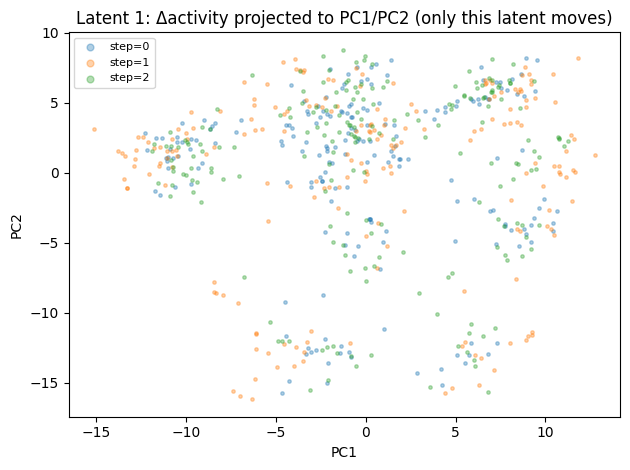

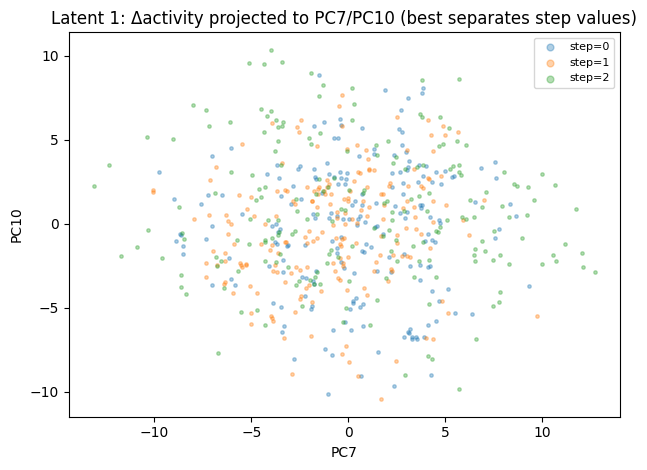

step=0 | abs cosine(sim) of step-PC1 with global PCs: [0.60745 0.25397 0.62246 0.11076 0.18565 0.03388 0.21323 0.03638]
step=1 | abs cosine(sim) of step-PC1 with global PCs: [0.78351 0.07157 0.44214 0.05007 0.07916 0.04712 0.00846 0.13601]
step=2 | abs cosine(sim) of step-PC1 with global PCs: [0.41504 0.29107 0.03769 0.25543 0.40933 0.33946 0.49448 0.08959]


In [17]:
# 1) Build dict step_value -> activity samples, for latent k
k = 1  # e.g. position latent index
activity_by_step = collect_activity_by_step_value(
    model, analysis_loader, latent_idx=k,
    feature="activity",   # usually best for "dynamics"
    activity_start_recording=1,
    zero_tol=1e-9,
    max_points_per_step=200,
    time_subsample=1,
)

# 2) Fit global PCA and rank components by step separation
pca, scaler, Z, y, steps = fit_global_pca_from_activity_dict(activity_by_step, n_components=20, standardize=True)
order, F, pvals = rank_pcs_by_step_separation(Z, y)

print("Steps (unique context values):", steps)
print("Top PCs by step-separation:", order[:10])
print("Their F-scores:", F[order[:10]])

# 3a) Plot usual PC1/PC2
plot_2d_projection_by_step(
    pca, scaler, activity_by_step, steps,
    pcs=(0, 1),
    title=f"Latent {k}: Δactivity projected to PC1/PC2 (only this latent moves)"
)

# 3b) Plot the *most step-discriminative* pair (often not (0,1))
pc_a, pc_b = int(order[0]), int(order[1])
plot_2d_projection_by_step(
    pca, scaler, activity_by_step, steps,
    pcs=(pc_a, pc_b),
    title=f"Latent {k}: Δactivity projected to PC{pc_a+1}/PC{pc_b+1} (best separates step values)"
)

# 4) Compare per-step PCA loadings to global PCA
sims, steps = compare_step_pca_loadings_to_global(activity_by_step, n_components=8, standardize=True)
# Example: print alignment of step s's first PC with global PCs
for s in steps:
    print(f"step={s:g} | abs cosine(sim) of step-PC1 with global PCs:", sims[s][0])
    
    

In [18]:
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



def mask_only_target_moves(ctx, latent_idx, *, zero_tol=1e-9, use_abs=True):
    """
    ctx: [B, L] step sizes (discrete)
    mask True where ONLY latent_idx has nonzero step (others ~0)
    """
    c = ctx.abs() if use_abs else ctx
    step = c[:, latent_idx]  # [B]
    others = torch.cat([c[:, :latent_idx], c[:, latent_idx+1:]], dim=1)  # [B,L-1]
    others_zero = (others.abs() <= zero_tol).all(dim=1)
    target_nonzero = step.abs() >=0
    mask = others_zero & target_nonzero
    return mask, step


def _reduce_latent_value(z, reduce="first"):
    """
    z: [..., D] latent slice values
    returns: [...] scalar
    """
    if z.dim() == 1:
        return z
    if z.shape[-1] == 1:
        return z[..., 0]
    if reduce == "first":
        return z[..., 0]
    if reduce == "norm":
        return torch.linalg.norm(z, dim=-1)
    if reduce == "mean":
        return z.mean(dim=-1)
    raise ValueError("Unknown reduce: {}".format(reduce))


@torch.no_grad()
def collect_activity_and_latentcolor_by_step_value(
    model,
    loader,
    latent_idx_or_slice,
    *,
    activity_start_recording=None,
    feature="delta_activity",        # "activity" or "delta_activity"
    color_time="post",               # for delta_activity: "pre" or "post"
    latent_value_reduce="first",     # if slice gives multi-dim: "first"|"norm"|"mean"
    zero_tol=1e-9,
    use_abs_context=True,
    max_points_per_step=20000,
    time_subsample=1,
    seed=0,
):
    """
    Assumes batch = (x, latents, ctx)
      - latents is [T,B,L] or [B,T,L]
      - ctx is [B,L] (step sizes / dynamics spec)
    Returns:
      out: dict step_value -> (X, c)
        X: [M,N] activity samples
        c: [M] latent values aligned to each row in X (for coloring)
    """
    rng = np.random.default_rng(seed)
    model.eval()

    # normalize latent selector
    if isinstance(latent_idx_or_slice, (int, np.integer)):
        sl = slice(int(latent_idx_or_slice), int(latent_idx_or_slice) + 1)
    else:
        sl = latent_idx_or_slice

    buckets = {}  # step -> list of (X_block [m,N], c_block [m])

    for batch in loader:
        x, latents, ctx = batch

        mask, step = mask_only_target_moves(ctx, sl.start if isinstance(sl, slice) else int(sl),
                                            zero_tol=zero_tol, use_abs=use_abs_context)
        if mask.sum().item() == 0:
            continue

        _, _, activity, _ = model(x)  # activity [T,B,N]
        A = activity

        # align start recording
        start = activity_start_recording if activity_start_recording is not None else 0
        if start > 0:
            A = A[start:]
            lat_use = latents[start:]
        else:
            lat_use = latents

        if feature == "delta_activity":
            Afeat = A[1:] - A[:-1]    # [T-1,B,N]
            if color_time == "post":
                Z = lat_use[1:, :, sl]     # latent at t+1
            elif color_time == "pre":
                Z = lat_use[:-1, :, sl]    # latent at t
            else:
                raise ValueError("color_time must be 'pre' or 'post' for delta_activity")
        elif feature == "activity":
            Afeat = A                      # [T,B,N]
            Z = lat_use[:, :, sl]          # [T,B,D]
        else:
            raise ValueError("feature must be 'activity' or 'delta_activity'")

        # reduce latent slice to scalar for color
        Z = _reduce_latent_value(Z, reduce=latent_value_reduce)  # [T',B]

        # optional time subsample
        if time_subsample > 1:
            Afeat = Afeat[::time_subsample]
            Z = Z[::time_subsample]

        # select sequences
        A_sel = Afeat[:, mask, :]           # [T',Bsel,N]
        Z_sel = Z[:, mask]                  # [T',Bsel]
        step_sel = step[mask].detach().cpu()  # [Bsel]

        A_sel = A_sel.detach().cpu().numpy()
        Z_sel = Z_sel.detach().cpu().numpy()

        Tprime, Bsel, N = A_sel.shape
        for j in range(Bsel):
            s = float(step_sel[j].item())
            X_block = A_sel[:, j, :]        # [T',N]
            c_block = Z_sel[:, j]           # [T']

            if s not in buckets:
                buckets[s] = []
            buckets[s].append((X_block, c_block))

    # concat + cap per step (cap applied consistently to X and c)
    out = {}
    for s, blocks in buckets.items():
        X = np.concatenate([b[0] for b in blocks], axis=0)
        c = np.concatenate([b[1] for b in blocks], axis=0)

        if max_points_per_step is not None and X.shape[0] > max_points_per_step:
            idx = rng.choice(X.shape[0], size=max_points_per_step, replace=False)
            X = X[idx]
            c = c[idx]

        out[s] = (X, c)

    if len(out) == 0:
        raise RuntimeError("No samples found where only the requested latent moves.")
    return out


def fit_global_pca_from_buckets(activity_color_by_step, n_components=20, standardize=True):
    steps = sorted(activity_color_by_step.keys())
    X_all = np.concatenate([activity_color_by_step[s][0] for s in steps], axis=0)
    y_step = np.concatenate([np.full(activity_color_by_step[s][0].shape[0], i) for i, s in enumerate(steps)])

    scaler = StandardScaler() if standardize else None
    Xs = scaler.fit_transform(X_all) if scaler is not None else X_all

    pca = PCA(n_components=n_components, random_state=0).fit(Xs)
    Z = pca.transform(Xs)

    return pca, scaler, Z, y_step, steps


def pick_best_pc_pair_by_step_separation(Z, y_step):
    F, p = f_classif(Z, y_step)
    order = np.argsort(-F)
    return (int(order[0]), int(order[1])), F, p


def plot_pca_scatter_colored_by_latent(activity_color_by_step, pca, scaler, *,
                                       pcs=(0, 1),
                                       per_step=True,
                                       max_points_per_step=5000,
                                       title=None):
    """
    If per_step=True: one figure per step value (cleanest).
    If per_step=False: one combined plot.
    """
    steps = sorted(activity_color_by_step.keys())

    if per_step:
        for s in steps:
            X, c = activity_color_by_step[s]
            if max_points_per_step is not None and X.shape[0] > max_points_per_step:
                idx = np.random.choice(X.shape[0], size=max_points_per_step, replace=False)
                Xp = X[idx]
                cp = c[idx]
            else:
                Xp, cp = X, c

            Xs = scaler.transform(Xp) if scaler is not None else Xp
            Zp = pca.transform(Xs)

            plt.figure()
            sc = plt.scatter(Zp[:, pcs[0]], Zp[:, pcs[1]], c=cp, s=6, alpha=0.5)
            plt.xlabel("PC{}".format(pcs[0] + 1))
            plt.ylabel("PC{}".format(pcs[1] + 1))
            plt.title(f"{title} step = {s}")
            cb = plt.colorbar(sc)
            cb.set_label("latent value")
            plt.tight_layout()
            plt.show()
    else:
        # combined
        X_all, c_all = [], []
        for s in steps:
            X, c = activity_color_by_step[s]
            if max_points_per_step is not None and X.shape[0] > max_points_per_step:
                idx = np.random.choice(X.shape[0], size=max_points_per_step, replace=False)
                X = X[idx]
                c = c[idx]
            X_all.append(X)
            c_all.append(c)

        X_all = np.concatenate(X_all, axis=0)
        c_all = np.concatenate(c_all, axis=0)

        Xs = scaler.transform(X_all) if scaler is not None else X_all
        Zp = pca.transform(Xs)

        plt.figure()
        sc = plt.scatter(Zp[:, pcs[0]], Zp[:, pcs[1]], c=c_all, s=6, alpha=0.35)
        plt.xlabel("PC{}".format(pcs[0] + 1))
        plt.ylabel("PC{}".format(pcs[1] + 1))
        if title is not None:
            plt.title(title)
        cb = plt.colorbar(sc)
        cb.set_label("latent value")
        plt.tight_layout()
        plt.show()

In [19]:
# 1) Collect buckets: step_value -> (activity_samples, latent_values_for_color)
buckets = collect_activity_and_latentcolor_by_step_value(
    model,
    analysis_loader,
    latent_idx_or_slice=0,          # your latent index (or slice)
    feature="activity",       # good for dynamics
    color_time="post",              # color by latent(t+1) for delta_activity
    activity_start_recording=1,
    time_subsample=1,
    max_points_per_step=30000,
)


In [20]:
# 2) Fit global PCA
pca, scaler, Z, y_step, steps = fit_global_pca_from_buckets(buckets, n_components=30)


In [21]:
# 3) Pick PCs that best separate step values (often not PC1/PC2)
(best_a, best_b), F, p = pick_best_pc_pair_by_step_separation(Z, y_step)


In [22]:
best_a, best_b

(20, 28)

In [ ]:



# # 4) Plot (one plot per step, points colored by latent value)
# for i in range(27):
#     print("ERRERERERER")
#     plot_pca_scatter_colored_by_latent(
#         buckets, pca, scaler,
#         # pcs=(best_a, best_b),
#         pcs=(i, i+1),
#         per_step=True,
#         title=f"Latent 0 moves: PC{i+1} vs PC{i+2} (colored by latent value)"
# )

In [23]:
import numpy as np
from sklearn.linear_model import Ridge,Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def fit_latent_aligned_2d_from_buckets(
    buckets,
    *,
    neuron_idx=None,          # optional: restrict to subset of neurons
    standardize=True,
    ridge_alpha=1.0,
):
    # concatenate across step values
    steps = sorted(buckets.keys())
    X = np.concatenate([buckets[s][0] for s in steps], axis=0)  # [M,N]
    c = np.concatenate([buckets[s][1] for s in steps], axis=0)  # [M]

    if neuron_idx is not None:
        X = X[:, neuron_idx]

    scaler = StandardScaler() if standardize else None
    Xs = scaler.fit_transform(X) if scaler is not None else X

    # axis 1: ridge decoder direction for latent value
    reg = Lasso(alpha=ridge_alpha, fit_intercept=True)
    reg.fit(Xs, c)
    w = reg.coef_.astype(np.float64)  # [N]
    w /= (np.linalg.norm(w) + 1e-12)

    # residualize X wrt axis 1
    z1 = Xs @ w                        # [M]
    Xr = Xs - np.outer(z1, w)          # [M,N]

    # axis 2: top variance orthogonal direction (PCA on residuals)
    v2 = PCA(n_components=1, random_state=0).fit(Xr).components_[0]  # [N]
    v2 /= (np.linalg.norm(v2) + 1e-12)

    W = np.stack([w, v2], axis=1)      # [N,2]
    return W, scaler, steps

def project_buckets(buckets, W, scaler=None, neuron_idx=None):
    proj = {}
    for s, (X, c) in buckets.items():
        if neuron_idx is not None:
            X = X[:, neuron_idx]
        Xs = scaler.transform(X) if scaler is not None else X
        Z = Xs @ W  # [M,2]
        proj[s] = (Z, c)
    return proj

def plot_latent_aligned_scatter(proj, *, title=None, max_points_per_step=5000):
    steps = sorted(proj.keys())
    for s in steps:
        Z, c = proj[s]
        if max_points_per_step is not None and Z.shape[0] > max_points_per_step:
            idx = np.random.choice(Z.shape[0], size=max_points_per_step, replace=False)
            Zp, cp = Z[idx], c[idx]
        else:
            Zp, cp = Z, c

        plt.figure()
        sc = plt.scatter(Zp[:,0], Zp[:,1], c=cp, s=6, alpha=0.5)
        plt.xlabel("latent-aligned axis (decoder)")
        plt.ylabel("orthogonal residual axis (PC1 on residuals)")
        plt.title(title if title is not None else f"step={s:g}")
        cb = plt.colorbar(sc)
        cb.set_label("latent value")
        plt.tight_layout()
        plt.show()

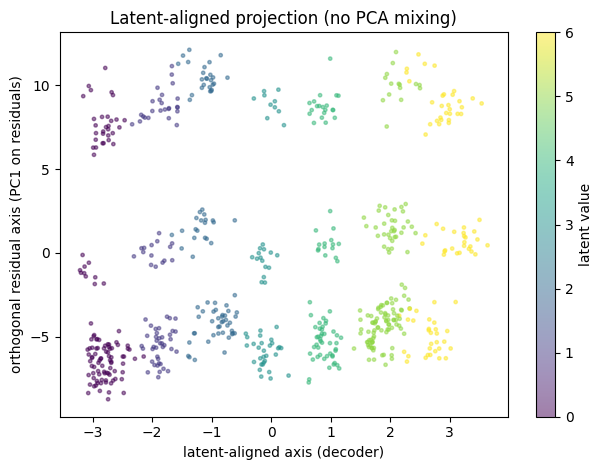

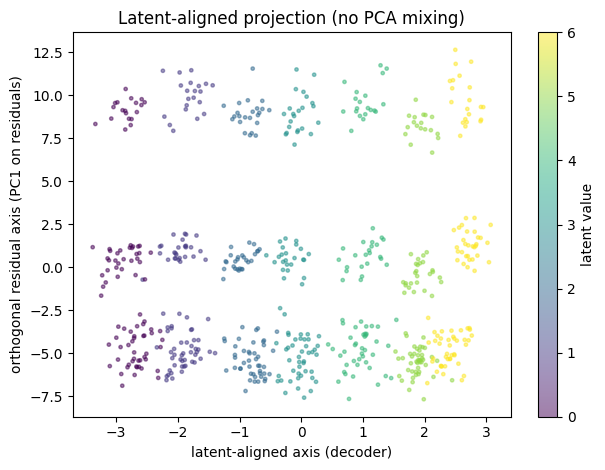

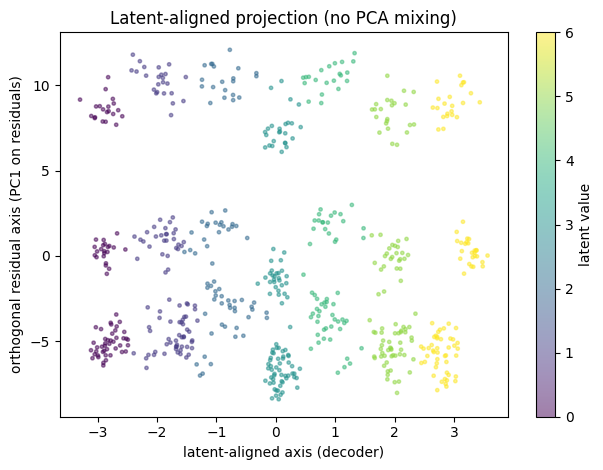

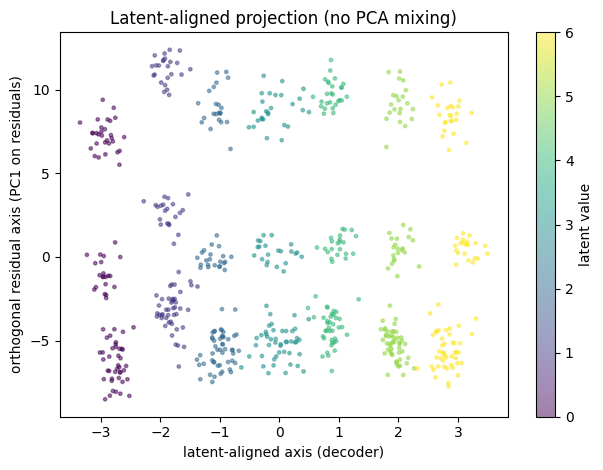

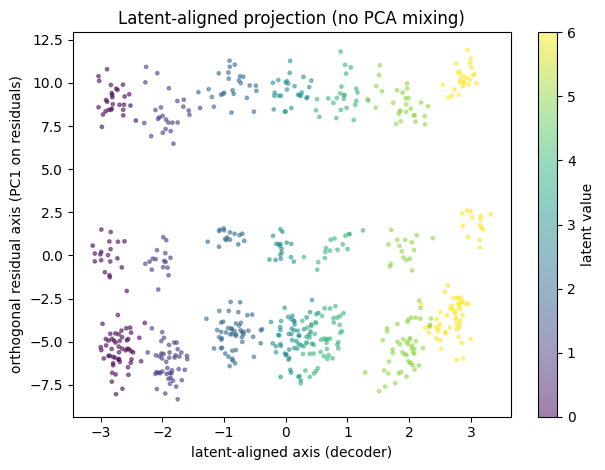

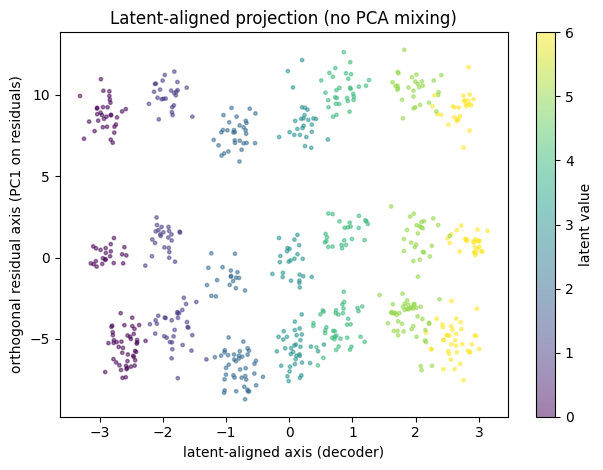

In [24]:
# buckets = {step: (X, latent_value)}  # from your collection code
W, scaler, steps = fit_latent_aligned_2d_from_buckets(
    buckets,
    neuron_idx=None,      # or pass coding-neuron subset here
    ridge_alpha=0.01,
)

proj = project_buckets(buckets, W, scaler=scaler)
plot_latent_aligned_scatter(proj, title="Latent-aligned projection (no PCA mixing)")

In [ ]:
import numpy as np
import torch
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


@torch.no_grad()
def _collect_stepwise_Xy_for_latent_change(
    model,
    loader,
    latent_idx_or_slice,
    *,
    subsample_batch=1,
    eps=1e-6,
    feature="delta_activity",   # "delta_activity" or "activity"
    require_exactly_one=False,
    other_latent_slices=None,   # list of slices/idx for other latents if require_exactly_one=True
):
    """
    Returns X [M,N], y [M] where y=1 if target latent changes from t->t+1.

    - feature="delta_activity": X_t = h_{t+1}-h_t
    - feature="activity":       X_t = h_t
    """
    model.eval()
    Xs, ys = [], []

    # normalize latent index input
    def _as_slice(x):
        if isinstance(x, (int, np.integer)):
            return slice(int(x), int(x) + 1)
        return x

    target_sl = _as_slice(latent_idx_or_slice)
    other_sls = None
    if other_latent_slices is not None:
        other_sls = [_as_slice(s) for s in other_latent_slices]

    for batch in loader:
        imgs, latents, contexts = batch             # [T,B,...], [T,B,L]
        if subsample_batch < 1:
            B = imgs.shape[1]
            idx = torch.randperm(B)[:max(2, int(subsample_batch * B))]
            imgs = imgs[:, idx]
            latents = latents[:, idx]
            contexts = contexts[idx]
        _, _, activity, _ = model(imgs)  
        # expected [T,B,N]
        A = activity.detach().cpu()               # [T,B,N]
        L = latents.detach().cpu()                    # [T,B,L]

        dL = contexts.unsqueeze(0).repeat(A.shape[0] - 1, 1, 1).cpu()  # [T-1,B,L]
        dA = A[1:] - A[:-1]                       # [T-1,B,N]

        # y: target latent changed?
        y = (dL[..., target_sl].abs().amax(dim=-1) > eps)  # [T-1,B], bool

        if require_exactly_one:
            if other_sls is None:
                raise ValueError("require_exactly_one=True needs other_latent_slices=[...]")
            changed_others = []
            for sl in other_sls:
                changed_others.append(dL[..., sl].abs().amax(dim=-1) > eps)  # [T-1,B]
            changed_others = torch.stack(changed_others, dim=-1)          # [T-1,B,K]
            # keep only steps where target changed XOR others didn't change:
            keep = (y & (changed_others.sum(dim=-1) == 0))
        else:
            keep = torch.ones_like(y, dtype=torch.bool)

        if feature == "delta_activity":
            X = dA
        elif feature == "activity":
            X = A[:-1]
        else:
            raise ValueError("feature must be 'delta_activity' or 'activity'")

        X = X[keep].reshape(-1, X.shape[-1])      # [M,N]
        y = y[keep].reshape(-1).to(torch.int64)   # [M]

        if X.numel() == 0:
            continue

        Xs.append(X)
        ys.append(y)

    if len(Xs) == 0:
        raise RuntimeError("No samples collected. Check eps/require_exactly_one/latent slices.")

    X = torch.cat(Xs, dim=0).numpy()
    y = torch.cat(ys, dim=0).numpy()
    print(f"Collected {X.shape[0]} samples with {X.shape[1]} features for latent_idx_or_slice={latent_idx_or_slice}")
    return X, y


def dynamic_neuron_superset_stability(
    model,
    train_loader,
    val_loader,
    latent_idx_or_slice,
    *,
    subsample_batch=1,
    eps=1e-6,
    feature="delta_activity",
    require_exactly_one=False,
    other_latent_slices=None,
    # stability selection params
    n_boot=100,
    sample_frac=0.8,
    C_grid=(0.05, 0.1, 0.3, 1.0, 3.0, 10.0),
    freq_threshold=0.2,
    max_iter=5000,
    random_state=0,
):
    """
    Finds a *superset* of neurons coding for the dynamics (change) of a latent via
    union/stability selection over sparse multivariate models.

    Returns dict with:
      - freq: [N] selection frequency
      - union_mask: [N] bool
      - stable_mask: [N] bool (freq >= freq_threshold)
      - avg_abs_w: [N] avg |weight| over fits where selected
      - ranked_neurons: list of neuron indices (most frequent first)
      - train_acc_mean, val_acc_mean: mean accuracies over successful fits
      - n_fits_success: number of successful fits
    """
    # build datasets
    Xtr, ytr = _collect_stepwise_Xy_for_latent_change(
        model, train_loader, latent_idx_or_slice,
        eps=eps, feature=feature,
        require_exactly_one=require_exactly_one,
        other_latent_slices=other_latent_slices,
        subsample_batch=subsample_batch,
    )
    Xva, yva = _collect_stepwise_Xy_for_latent_change(
        model, val_loader, latent_idx_or_slice,
        eps=eps, feature=feature,
        require_exactly_one=require_exactly_one,
        other_latent_slices=other_latent_slices,
        subsample_batch=subsample_batch,
    )

    M, N = Xtr.shape
    rng = np.random.default_rng(random_state)

    selected_counts = np.zeros(N, dtype=np.int64)
    absw_sums = np.zeros(N, dtype=np.float64)
    absw_counts = np.zeros(N, dtype=np.int64)

    train_accs, val_accs = [], []
    n_success = 0

    # precompute indices for speed
    n_sub = max(2, int(sample_frac * M))

    for b in range(n_boot):
        
        idx = rng.integers(0, M, size=n_sub)  # bootstrap w/ replacement
        Xb, yb = Xtr[idx], ytr[idx]
        # skip degenerate bootstraps (all one class)
        if np.unique(yb).size < 2:
            continue
        print(f"Bootstrap {b}: training logistic regression with {Xb.shape[0]} samples...")
        for C in C_grid:
            clf = make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    penalty="l1",
                    solver="saga",
                    C=float(C),
                    max_iter=max_iter,
                    random_state=(random_state + 1000 * b + int(10 * C)),
                ),
            )

            try:
                clf.fit(Xb, yb)
            except Exception:
                continue

            w = clf.named_steps["logisticregression"].coef_.reshape(-1)  # [N]
            nz = np.abs(w) > 1e-12

            selected_counts[nz] += 1
            absw_sums[nz] += np.abs(w[nz])
            absw_counts[nz] += 1

            train_accs.append(clf.score(Xb, yb))
            val_accs.append(clf.score(Xva, yva))
            n_success += 1

    if n_success == 0:
        raise RuntimeError("All fits failed/skipped. Try larger sample_frac, smaller eps, or fewer constraints.")

    freq = selected_counts / float(n_success)
    union_mask = freq > 0
    stable_mask = freq >= float(freq_threshold)
    avg_abs_w = np.zeros(N, dtype=np.float64)
    ok = absw_counts > 0
    avg_abs_w[ok] = absw_sums[ok] / absw_counts[ok]

    # rank by (freq, avg_abs_w)
    ranked_neurons = np.lexsort((-avg_abs_w, -freq)).tolist()

    return {
        "freq": freq,
        "union_mask": union_mask,
        "stable_mask": stable_mask,
        "avg_abs_w": avg_abs_w,
        "ranked_neurons": ranked_neurons,
        "train_acc_mean": float(np.mean(train_accs)),
        "val_acc_mean": float(np.mean(val_accs)),
        "n_fits_success": int(n_success),
        "X_shape": Xtr.shape,
        "feature": feature,
        "eps": eps,
        "require_exactly_one": require_exactly_one,
    }

In [ ]:
out = dynamic_neuron_superset_stability(
    model, analysis_loader, val_loader,
    subsample_batch=0.02,
    latent_idx_or_slice=0,          # “position” column
    feature="activity",       # best for dynamics
    n_boot=100,
    C_grid=[10],
    freq_threshold=0.2,
)
pos_union = np.where(out["union_mask"])[0]
pos_stable = np.where(out["stable_mask"])[0]
top20 = out["ranked_neurons"][:20]

In [ ]:
import numpy as np
import torch
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.preprocessing import StandardScaler

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def unpack_batch(batch):
    if len(batch) == 3:
        prim_sequence_inputs, latents, _ = batch
    else:
        prim_sequence_inputs, latents = batch
    prim_sequence_inputs = prim_sequence_inputs.transpose(0, 1).to(DEVICE)  # [T,B,...]
    latents = latents.transpose(0, 1).to(DEVICE)                            # [T,B,L]
    return prim_sequence_inputs, latents


@torch.no_grad()
def _collect_activity_and_latent(
    model,
    loader,
    latent_idx_or_slice,
    activity_mode="last",   # "last" or "all"
    activity_feature="activity",  # "activity" or "delta_activity"
    latent_transform=None,
):
    """
    Returns:
      X: [M, N]  neuron activity features
      Y: [M] or [M, D] latent target (possibly multi-dim if slice)
    """
    model.eval()
    Xs, Ys = [], []

    def _as_slice(x):
        if isinstance(x, (int, np.integer)):
            return slice(int(x), int(x) + 1)
        return x

    sl = _as_slice(latent_idx_or_slice)
    subsample_batch = 0.01
    for batch in loader:
        x, lat, contexts = batch          # [T,B,...], [T,B,L]
        if subsample_batch < 1:
            B = x.shape[1]
            idx = torch.randperm(B)[:max(2, int(subsample_batch * B))]
            x = x[:, idx]
            lat = lat[:, idx]
            contexts = contexts[idx]

        _, _, activity, _ = model(x)          # expected [T,B,N]
        A = activity.detach().cpu()           # [T,B,N]
        L = lat.detach().cpu()                # [T,B,L]

        if activity_feature == "delta_activity":
            Afeat = A[1:] - A[:-1]            # [T-1,B,N]
            Luse = L[1:]                      # align with delta step
        elif activity_feature == "activity":
            Afeat = A                          # [T,B,N]
            Luse = L
        else:
            raise ValueError("activity_feature must be 'activity' or 'delta_activity'")

        if activity_mode == "last":
            Xt = Afeat[-1]                    # [B,N]
            Yt = Luse[-1, :, sl]              # [B,D]
        elif activity_mode == "all":
            Xt = Afeat.flatten(0, 1)          # [T*B,N] or [(T-1)*B,N]
            Yt = Luse[:, :, sl].flatten(0, 1) # [T*B,D] or [(T-1)*B,D]
        else:
            raise ValueError("activity_mode must be 'last' or 'all'")

        if latent_transform is not None:
            # latent_transform expects numpy array [M,D] and returns [M] or [M,D2]
            Yt = torch.from_numpy(latent_transform(Yt.numpy()))

        Xs.append(Xt)
        Ys.append(Yt)

    X = torch.cat(Xs, dim=0).numpy()
    Y = torch.cat(Ys, dim=0).numpy()
    print(f"Collected X shape {X.shape} and Y shape {Y.shape} for latent_idx_or_slice={latent_idx_or_slice}")
    return X, Y


def _mi_vector(X, y, discrete_target, n_neighbors=5, seed=0):
    """
    X: [M,N], y: [M] continuous or discrete
    returns mi: [N]
    """
    Xs = StandardScaler().fit_transform(X)  # crucial for kNN MI
    if discrete_target:
        # y should be integers/classes
        mi = mutual_info_classif(
            Xs, y.astype(int),
            discrete_features=False,
            n_neighbors=n_neighbors,
            random_state=seed
        )
    else:
        mi = mutual_info_regression(
            Xs, y.astype(float),
            discrete_features=False,
            n_neighbors=n_neighbors,
            random_state=seed
        )
    return np.asarray(mi)


def _permutation_max_threshold(X, y, discrete_target, n_perm=200, alpha=0.01, n_neighbors=5, seed=0):
    """
    Family-wise threshold using max over neurons for each permutation.
    """
    rng = np.random.default_rng(seed)
    max_vals = np.zeros(n_perm, dtype=float)
    for p in range(n_perm):
        y_perm = rng.permutation(y)
        mi_perm = _mi_vector(X, y_perm, discrete_target, n_neighbors=n_neighbors, seed=seed + p + 1)
        max_vals[p] = float(mi_perm.max())
    return float(np.quantile(max_vals, 1.0 - alpha))


def all_neurons_coding_for_latent_mi(
    model,
    train_loader,
    val_loader,
    latent_idx_or_slice,
    *,
    # choose what "neuron signal" means
    activity_mode="all",            # "all" usually gives more power than "last"
    activity_feature="activity",    # "delta_activity" can be useful if you care about transitions
    # choose what "latent" means
    discrete_target=False,          # True for categorical (shape/color IDs), False for continuous (position)
    latent_transform=None,          # e.g. for one-hot -> argmax, or binning a continuous latent
    # stats
    n_neighbors=5,
    n_perm=200,
    alpha=0.01,
    seed=0,
    # how to aggregate multi-dim slices
    agg="max",                      # "max" or "sum" across dims if slice returns D>1
):
    """
    Returns a *large set* of neurons that individually carry info about the latent.
    Uses MI + permutation max-test (FWER control).

    Output dict:
      - mi_train: [N] aggregated MI score per neuron (after agg)
      - mi_train_by_dim: [D,N] if latent is multi-dim else [1,N]
      - threshold: float
      - selected_idx: np.ndarray of neuron indices passing threshold
      - mi_val: [N] aggregated MI on validation (same aggregation)
      - ranked_idx: neurons sorted by mi_train descending
    """
    Xtr, Ytr = _collect_activity_and_latent(
        model, train_loader, latent_idx_or_slice,
        activity_mode=activity_mode,
        activity_feature=activity_feature,
        latent_transform=latent_transform,
    )
    Xva, Yva = _collect_activity_and_latent(
        model, val_loader, latent_idx_or_slice,
        activity_mode=activity_mode,
        activity_feature=activity_feature,
        latent_transform=latent_transform,
    )

    # Ensure Y is 2D for uniform handling
    if Ytr.ndim == 1:
        Ytr_2d = Ytr.reshape(-1, 1)
        Yva_2d = Yva.reshape(-1, 1)
    else:
        Ytr_2d = Ytr
        Yva_2d = Yva

    D = Ytr_2d.shape[1]
    N = Xtr.shape[1]

    mi_train_by_dim = np.zeros((D, N), dtype=float)
    mi_val_by_dim   = np.zeros((D, N), dtype=float)

    for d in range(D):
        mi_train_by_dim[d] = _mi_vector(Xtr, Ytr_2d[:, d], discrete_target, n_neighbors=n_neighbors, seed=seed)
        mi_val_by_dim[d]   = _mi_vector(Xva, Yva_2d[:, d], discrete_target, n_neighbors=n_neighbors, seed=seed)

    if agg == "max":
        mi_train = mi_train_by_dim.max(axis=0)
        mi_val   = mi_val_by_dim.max(axis=0)
        # threshold using worst-case (max over dims) under permutation
        # do permutation on a single aggregated target by permuting rows and recomputing max across dims
        # (approx) do it by using the most informative dim; safer is: threshold against max across dims:
        # We'll do the safe route: compute max across dims inside each perm.
        rng = np.random.default_rng(seed)
        max_vals = np.zeros(n_perm, dtype=float)
        Xs = StandardScaler().fit_transform(Xtr)
        for p in range(n_perm):
            print(f"Permutation {p+1}/{n_perm} for max aggregation threshold...")
            perm = rng.permutation(Xtr.shape[0])
            # recompute MI per dim with permuted y, then max across dims, then max across neurons
            tmp = np.zeros((D, N), dtype=float)
            for d in range(D):
                yp = Ytr_2d[perm, d]
                if discrete_target:
                    tmp[d] = mutual_info_classif(
                        Xs, yp.astype(int),
                        discrete_features=False,
                        n_neighbors=n_neighbors,
                        random_state=seed + p + 1
                    )
                else:
                    tmp[d] = mutual_info_regression(
                        Xs, yp.astype(float),
                        discrete_features=False,
                        n_neighbors=n_neighbors,
                        random_state=seed + p + 1
                    )
            max_vals[p] = float(tmp.max(axis=0).max())
        threshold = float(np.quantile(max_vals, 1.0 - alpha))

    elif agg == "sum":
        mi_train = mi_train_by_dim.sum(axis=0)
        mi_val   = mi_val_by_dim.sum(axis=0)
        # permutation threshold for sum aggregation
        # permute rows, recompute sum across dims, then take max across neurons
        rng = np.random.default_rng(seed)
        max_vals = np.zeros(n_perm, dtype=float)
        Xs = StandardScaler().fit_transform(Xtr)
        for p in range(n_perm):
            print(f"Permutation {p+1}/{n_perm} for sum aggregation threshold...")
            perm = rng.permutation(Xtr.shape[0])
            tmp_sum = np.zeros(N, dtype=float)
            for d in range(D):
                yp = Ytr_2d[perm, d]
                if discrete_target:
                    mi_d = mutual_info_classif(
                        Xs, yp.astype(int),
                        discrete_features=False,
                        n_neighbors=n_neighbors,
                        random_state=seed + p + 1
                    )
                else:
                    mi_d = mutual_info_regression(
                        Xs, yp.astype(float),
                        discrete_features=False,
                        n_neighbors=n_neighbors,
                        random_state=seed + p + 1
                    )
                tmp_sum += np.asarray(mi_d)
            max_vals[p] = float(tmp_sum.max())
        threshold = float(np.quantile(max_vals, 1.0 - alpha))
    else:
        raise ValueError("agg must be 'max' or 'sum'")

    selected_idx = np.where(mi_train >= threshold)[0]
    ranked_idx = np.argsort(-mi_train)

    return {
        "mi_train": mi_train,
        "mi_train_by_dim": mi_train_by_dim,
        "threshold": threshold,
        "selected_idx": selected_idx,
        "mi_val": mi_val,
        "mi_val_by_dim": mi_val_by_dim,
        "ranked_idx": ranked_idx,
        "X_shape": Xtr.shape,
        "activity_mode": activity_mode,
        "activity_feature": activity_feature,
        "discrete_target": discrete_target,
        "agg": agg,
    }

In [ ]:
latents = ["primitive", "color", "position"]

In [ ]:
latents_dicts = {}

for latents_idx, lat in enumerate(latents):
    out_pos = all_neurons_coding_for_latent_mi(
        model, analysis_loader, val_loader,
        latent_idx_or_slice=latents_idx,
        discrete_target=True,
        activity_mode="all",
        activity_feature="activity",
        n_perm=50,
        alpha=0.01,
        agg="max",
    )
    latents_dicts[lat] = out_pos
    print(f"Latent: {lat}, selected neurons: {len(out_pos['selected_idx'])}, threshold: {out_pos['threshold']:.4f}")
    

In [ ]:
out_pos["selected_idx"].shape